In [2]:
# =====================================================================
# ADD MAX PLACEMENTS WEIGHT - one-time pipeline correction
# =====================================================================
# Every analysis so far has counted 1 opportunity = 1 placement. That's
# wrong: an opportunity with Max Places = 3 represents 3 placement slots,
# not 1. This script joins the real capacity back onto the coded files so
# every downstream script can start summing "Max Placements" instead of
# just counting rows.
#
# WHAT THIS DOES NOT DO: re-run NIOCCS coding. The NAICS/SOC match for a
# posting doesn't change based on how many students it can hold - only
# the counting/weighting logic downstream needs to change, and that's
# intentionally left for the broader pipeline cleanup (Claude Code), not
# rewritten piecemeal here.
#
# Backs up both coded files before touching them, same safety pattern
# used for the Cultural Corps merge (Step 4).

import pandas as pd
import shutil
import os

SOURCE_PATH = "../../data/AllRoles_clean.csv"  # has Max Places; shared source for BOTH core hubs and Cultural Corps

TARGETS = [
    ("../../data/AllRoles_nioccs_coded.csv", "../../data/AllRoles_nioccs_coded_BACKUP_before_max_placements.csv"),
    ("../../data/AllRoles_nioccs_coded_with_education.csv", "../../data/AllRoles_nioccs_coded_with_education_BACKUP_before_max_placements.csv"),
]


def load_cleaned_max_places(source_path: str) -> pd.DataFrame:
    source = pd.read_csv(source_path, encoding="utf-8-sig", low_memory=False)
    mp = source[["Opportunity Id", "Max Places"]].rename(
        columns={"Opportunity Id": "Opportunity Identifier", "Max Places": "Max Placements"}
    )

    n_total = len(mp)
    n_missing = mp["Max Placements"].isna().sum()
    mp["Max Placements"] = pd.to_numeric(mp["Max Placements"], errors="coerce")
    n_non_numeric = mp["Max Placements"].isna().sum() - n_missing  # caught by coerce, not originally NaN

    # Cleaning rules - printed clearly so nothing is silently assumed:
    #   - missing or non-numeric -> treat as 1 (assume at least one real slot)
    #   - zero or negative -> treat as 1 (can't have a placement with 0 slots)
    #   - non-integer (e.g. "2.0") -> round to nearest int
    n_zero_or_negative = (mp["Max Placements"] <= 0).sum()

    print(f"Source rows: {n_total}")
    print(f"Missing Max Places (defaulted to 1): {n_missing}")
    print(f"Non-numeric Max Places (defaulted to 1): {n_non_numeric}")
    print(f"Zero or negative Max Places (defaulted to 1): {n_zero_or_negative}")

    mp["Max Placements"] = mp["Max Placements"].fillna(1)
    mp.loc[mp["Max Placements"] <= 0, "Max Placements"] = 1
    mp["Max Placements"] = mp["Max Placements"].round().astype(int)

    # Outlier handling: values more than 4 standard deviations from the
    # mean are almost certainly data-entry mistakes (a single posting
    # with 230 slots), not real capacity. Rather than let a handful of
    # bad rows distort every sector total downstream, replace them with
    # the mean. Computed once on the full cleaned distribution - both the
    # detection threshold and the replacement value use the same mean, so
    # this is transparent and reproducible, not tuned after the fact.
    mean_val = mp["Max Placements"].mean()
    std_val = mp["Max Placements"].std()
    threshold = mean_val + 4 * std_val
    outlier_mask = mp["Max Placements"] > threshold
    n_outliers = outlier_mask.sum()

    if n_outliers:
        print(f"\nOutlier check: mean={mean_val:.2f}, std={std_val:.2f}, threshold (mean + 4*std)={threshold:.2f}")
        print(f"{n_outliers} rows exceed the threshold - treating as data-entry mistakes, not real capacity:")
        print(mp.loc[outlier_mask, ["Opportunity Identifier", "Max Placements"]]
              .sort_values("Max Placements", ascending=False).to_string(index=False))
        replacement_value = int(round(mean_val))
        print(f"Replacing these {n_outliers} values with the mean ({replacement_value}).")
        mp.loc[outlier_mask, "Max Placements"] = replacement_value
        mp["Max Placements"] = mp["Max Placements"].astype(int)
    else:
        print(f"\nOutlier check: mean={mean_val:.2f}, std={std_val:.2f}, threshold (mean + 4*std)={threshold:.2f} - "
              f"no rows exceeded it, nothing replaced.")

    print(f"\nMax Placements distribution after cleaning AND outlier correction:")
    print(mp["Max Placements"].describe().to_string())
    print(f"\nRemaining top values (post-correction - should show no extreme outliers now):")
    print(mp["Max Placements"].value_counts().sort_index(ascending=False).head(10).to_string())

    # Duplicate Opportunity Identifiers would break the join below - guard
    # against it rather than silently producing a many-to-one merge.
    n_dupe_ids = mp["Opportunity Identifier"].duplicated().sum()
    if n_dupe_ids:
        print(f"\nWARNING: {n_dupe_ids} duplicate Opportunity Identifiers in the source - "
              f"keeping the first occurrence of each for the join.")
        mp = mp.drop_duplicates(subset=["Opportunity Identifier"], keep="first")

    return mp


def apply_join(coded_path: str, backup_path: str, max_places: pd.DataFrame):
    print(f"\n{'=' * 70}")
    print(f"Processing {coded_path}")
    print("=" * 70)

    if not os.path.exists(coded_path):
        print(f"SKIPPED - file doesn't exist: {coded_path}")
        return

    coded = pd.read_csv(coded_path, encoding="utf-8-sig")
    n_before = len(coded)

    if "Max Placements" in coded.columns:
        print("NOTE: 'Max Placements' column already exists - this file may have already "
              "been processed. Overwriting with a fresh join rather than skipping, in case "
              "the source data changed.")
        coded = coded.drop(columns=["Max Placements"])

    shutil.copy(coded_path, backup_path)
    print(f"Backed up to {backup_path}")

    merged = coded.merge(max_places, on="Opportunity Identifier", how="left")

    n_unmatched = merged["Max Placements"].isna().sum()
    if n_unmatched:
        print(f"WARNING: {n_unmatched} of {n_before} rows had no match in {SOURCE_PATH} - "
              f"these opportunities aren't in the source file. Defaulting their Max Placements "
              f"to 1 so nothing is silently dropped, but this is worth investigating - it "
              f"shouldn't happen if every coded row originated from AllRoles_clean.csv.")
        merged["Max Placements"] = merged["Max Placements"].fillna(1).astype(int)

    merged.to_csv(coded_path, index=False)

    total_opportunities = len(merged)
    total_placement_slots = merged["Max Placements"].sum()
    print(f"\nRows (opportunities): {total_opportunities}")
    print(f"Sum of Max Placements (actual placement capacity): {total_placement_slots}")
    print(f"Ratio: {total_placement_slots / total_opportunities:.2f} placements per opportunity, on average")
    print(f"\nWrote {coded_path} with 'Max Placements' column added.")


def main():
    print("Loading and cleaning Max Places from the shared source file...")
    max_places = load_cleaned_max_places(SOURCE_PATH)

    for coded_path, backup_path in TARGETS:
        apply_join(coded_path, backup_path, max_places)

    print("\n" + "=" * 70)
    print("NEXT STEP")
    print("=" * 70)
    print("Every downstream counting script (qcew_vs_internal_comparison.py, exploration_round2.py, "
          "raw_numbers_and_shares.py, historical_trend_raw_counts.py, build_detail_workbook.py) still "
          "counts opportunities (rows), not placements (Max Placements). That rewrite - switching "
          "value_counts()/COUNTIFS-style counting to sum 'Max Placements' instead - is the next piece, "
          "and given how many scripts that touches, it's the right scope for Claude Code to handle "
          "directly against your real notebook rather than patching piecemeal here.")


if __name__ == "__main__":
    main()

Loading and cleaning Max Places from the shared source file...
Source rows: 9297
Missing Max Places (defaulted to 1): 103
Non-numeric Max Places (defaulted to 1): 0
Zero or negative Max Places (defaulted to 1): 19

Outlier check: mean=2.83, std=6.59, threshold (mean + 4*std)=29.19
32 rows exceed the threshold - treating as data-entry mistakes, not real capacity:
              Opportunity Identifier  Max Placements
e9135376-5017-f011-81a3-90cb95efafa1             230
ba275376-5017-f011-81a3-90cb95efafa1             218
99225376-5017-f011-81a3-90cb95efafa1             215
c61d5376-5017-f011-81a3-90cb95efafa1             200
3b145376-5017-f011-81a3-90cb95efafa1             152
07145376-5017-f011-81a3-90cb95efafa1             150
82225376-5017-f011-81a3-90cb95efafa1             150
d82b5376-5017-f011-81a3-90cb95efafa1             135
8e1a5376-5017-f011-81a3-90cb95efafa1             135
f62b5376-5017-f011-81a3-90cb95efafa1             125
57ee2cd5-2531-48b7-5df6-08dd8653f927              60

In [3]:
# =====================================================================
# THE TRUTH ABOUT HEALTHCARE (and everything else): opportunities vs.
# actual placement capacity, side by side
# =====================================================================
# Step 1: flag the extreme Max Placements outliers so we can sanity-check
# before trusting anything downstream - a single posting with 230 slots
# is either a real large-scale program or a data entry error, and that
# distinction matters a lot before we call any new number "the truth."
#
# Step 2: recompute the same year/sector breakdown that produced Finding
# #1 (Healthcare = 722), but sum Max Placements instead of counting rows,
# for every sector side by side - so we see exactly what shifts and by
# how much, not just Healthcare in isolation.

import pandas as pd

READY_PATH = "../../data/AllRoles_nioccs_ready.csv"
CODED_PATH = "../../data/AllRoles_nioccs_coded_with_education.csv"
CITYWIDE_PATH = "../../data/qcew_nyc_sector_citywide.csv"

QCEW_SECTOR_TITLES = {
    "11": "Agriculture, Forestry, Fishing and Hunting", "21": "Mining, Quarrying, and Oil and Gas Extraction",
    "22": "Utilities", "23": "Construction", "31-33": "Manufacturing", "42": "Wholesale Trade",
    "44-45": "Retail Trade", "48-49": "Transportation and Warehousing", "51": "Information",
    "52": "Finance and Insurance", "53": "Real Estate and Rental and Leasing",
    "54": "Professional and Technical Services", "55": "Management of Companies and Enterprises",
    "56": "Administrative and Waste Services", "61": "Educational Services",
    "62": "Health Care and Social Assistance", "71": "Arts, Entertainment, and Recreation",
    "72": "Accommodation and Food Services", "81": "Other Services (except Public Administration)",
    "92": "Public Administration", "99": "Unclassified",
}


def naics_to_qcew_sector(naics_code):
    if pd.isna(naics_code):
        return None
    code = str(naics_code).strip()
    prefix2 = code[:2]
    if prefix2 in ("31", "32", "33"):
        return "31-33"
    if prefix2 in ("44", "45"):
        return "44-45"
    if prefix2 in ("48", "49"):
        return "48-49"
    return prefix2


ready = pd.read_csv(READY_PATH, encoding="utf-8-sig")
coded = pd.read_csv(CODED_PATH, encoding="utf-8-sig")

# ------------------------------------------------------------------
# Step 1: outlier sanity-check, BEFORE trusting anything downstream
# ------------------------------------------------------------------
print("=" * 70)
print("Top 15 largest Max Placements - sanity-check before trusting the totals")
print("=" * 70)
outlier_check = coded[["Opportunity Identifier", "Role Name", "Program Hub Category", "Max Placements"]].merge(
    ready[["Opportunity Identifier", "Agency Name", "Cohort Year"]], on="Opportunity Identifier", how="left"
).sort_values("Max Placements", ascending=False).head(15)
print(outlier_check.to_string(index=False))
print("\nIf any of these look like data entry errors (e.g. '230' meant to be '23' or '2.30'), "
      "flag them before treating the totals below as ground truth - one bad row can move a sector's "
      "total substantially given how skewed this distribution is (mean 2.83, median 2, max 230).")

# ------------------------------------------------------------------
# Step 2: old (row count) vs new (Max Placements sum), same filtering
# logic Finding #1 used - insufficient-info dropped, latest overlap year
# ------------------------------------------------------------------
merged = coded.merge(ready[["Opportunity Identifier", "Cohort Year"]], on="Opportunity Identifier", how="left")
merged = merged[merged["API Call Error"].isna()]
merged = merged[
    ~(merged["SOC Flagged As Insufficient Information"] | merged["NAICS Flagged As Insufficient Information"])
]
merged["QCEW Sector Title"] = merged["NAICS Code"].apply(naics_to_qcew_sector).map(QCEW_SECTOR_TITLES)

citywide = pd.read_csv(CITYWIDE_PATH)
overlap_years = sorted(set(merged["Cohort Year"].dropna()) & set(citywide["Cohort Year"]))
latest_year = max(overlap_years)
print(f"\n\nUsing {latest_year} (latest year with both internal and citywide data) - "
      f"same year Finding #1's original numbers used.")

latest = merged[merged["Cohort Year"] == latest_year]

old_counts = latest.groupby("QCEW Sector Title").size().rename("Old (Opportunities)")
new_counts = latest.groupby("QCEW Sector Title")["Max Placements"].sum().rename("New (Actual Placements)")

comparison = pd.concat([old_counts, new_counts], axis=1).fillna(0).astype(int)
comparison["Pct Change"] = ((comparison["New (Actual Placements)"] - comparison["Old (Opportunities)"])
                             / comparison["Old (Opportunities)"] * 100).round(1)
comparison = comparison.sort_values("New (Actual Placements)", ascending=False)

print("\n" + "=" * 70)
print(f"Old vs. New, every sector, {latest_year}")
print("=" * 70)
print(comparison.to_string())

print(f"\n{'=' * 70}")
print("HEALTHCARE SPECIFICALLY (Finding #1)")
print("=" * 70)
if "Health Care and Social Assistance" in comparison.index:
    hc = comparison.loc["Health Care and Social Assistance"]
    print(f"Old (opportunities): {hc['Old (Opportunities)']}")
    print(f"New (actual placements): {hc['New (Actual Placements)']}")
    print(f"Change: {hc['Pct Change']}%")

total_old = latest.shape[0]
total_new = latest["Max Placements"].sum()
print(f"\nTotal, all sectors: {total_old} opportunities -> {total_new} actual placements "
      f"({(total_new - total_old) / total_old * 100:.1f}% change)")

Top 15 largest Max Placements - sanity-check before trusting the totals
              Opportunity Identifier                                                                              Role Name Program Hub Category  Max Placements                                         Agency Name  Cohort Year
c4195376-5017-f011-81a3-90cb95efafa1                                                     Wellness Intern - Exuding Wellness           Healthcare              28                                    Exuding Wellness       2025.0
af2a5376-5017-f011-81a3-90cb95efafa1                                     Unadat.com I Software Developer Engineering Intern       STEM and Green              26                                              Unadat       2025.0
7df87427-0c96-44cf-a6a7-08de6fd96e5d                                        Primary Care Intern - Maimonides Medical Center           Healthcare              26                           Maimonides Medical Center       2026.0
19165376-5017-f011-81a3-

Rows after standard filtering: 7434
Excluded 1056 Cultural Corps rows (core programs only).
Overlap years: [2022, 2023, 2024, 2025] | latest=2025, first=2022

TABLE 1: Full sector summary, 2025 (no representation ratio)
                                               Our_Placements  Our_Pct_Of_Total  Citywide_Pct_Of_Total  Citywide_Pct_Growth
QCEW Sector Title                                                                                                          
Health Care and Social Assistance                      1791.0             43.43                  24.63                 19.3
Professional and Technical Services                     913.0             22.14                  10.55                 -0.5
Educational Services                                    368.0              8.92                   4.97                  7.6
Information                                             340.0              8.24                   5.18                 -7.1
Arts, Entertainment, and Recreation 

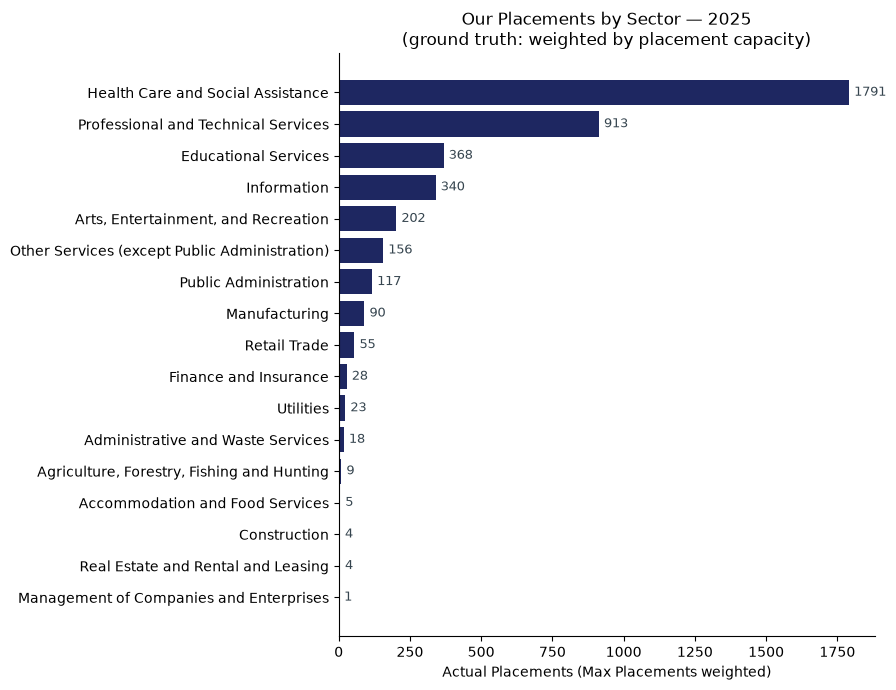

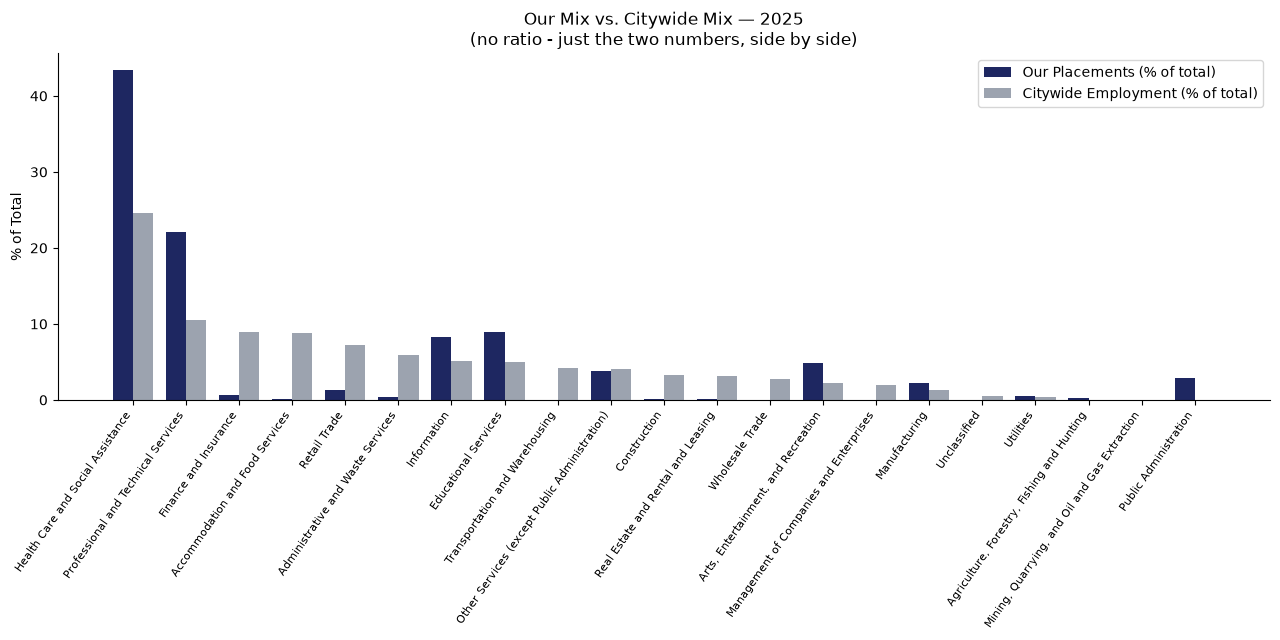

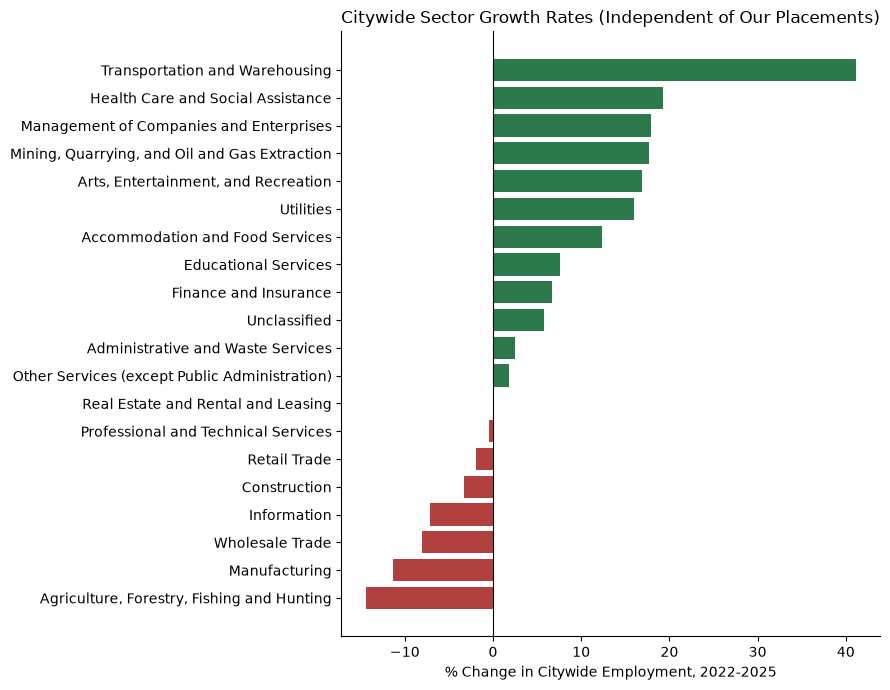

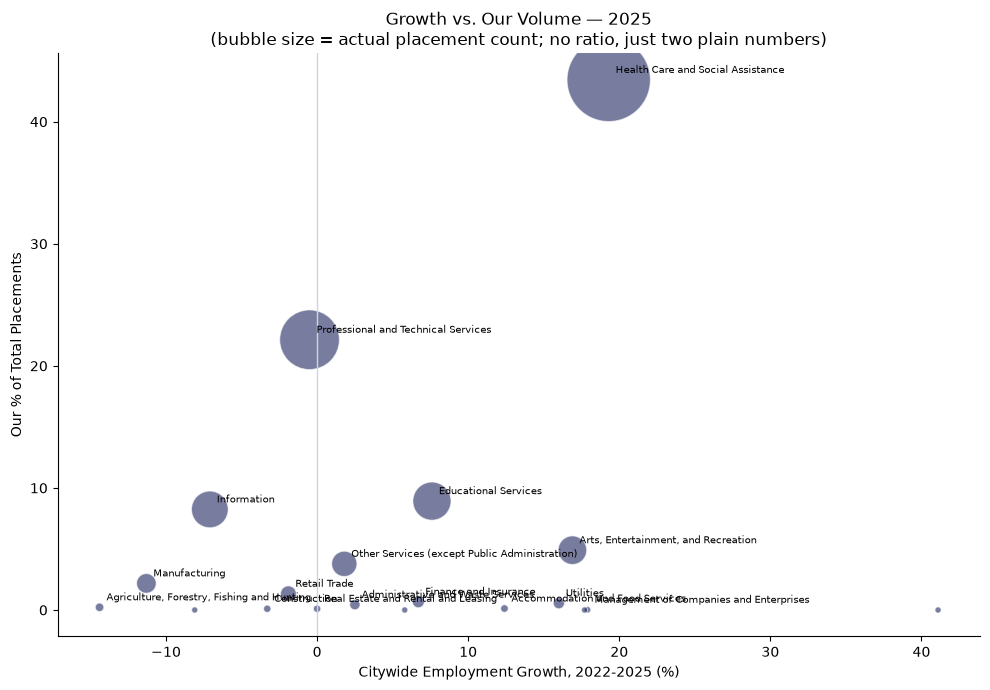

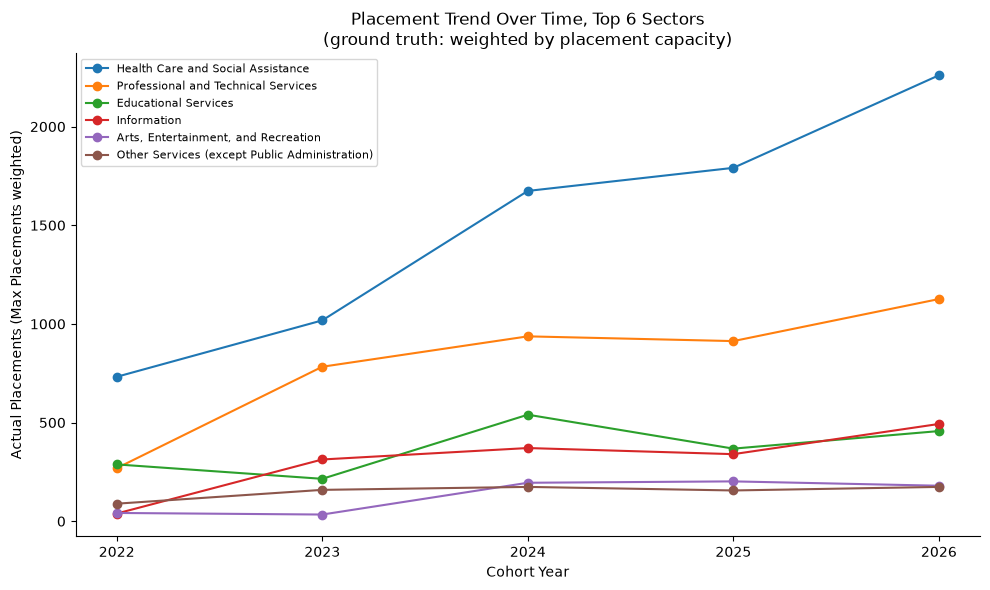


All charts and tables written to ../../data/ (gt_chart1 through gt_chart5, ground_truth_summary_latest_year.csv, ground_truth_trend_all_years.csv)


In [1]:
# =====================================================================
# GROUND TRUTH ANALYSIS - everything needed for the next deck version
# =====================================================================
# Consolidates what used to be four separate scripts
# (qcew_vs_internal_comparison.py, exploration_round2.py,
# raw_numbers_and_shares.py, historical_trend_raw_counts.py) into one,
# now that:
#   1. Counts are weighted by Max Placements (actual capacity), not just
#      opportunity rows - run add_max_placements_weight.py first if you
#      haven't already.
#   2. The representation ratio (our % / citywide %) is dropped entirely -
#      too hard to explain. Everywhere it used to appear, this shows our
#      % and citywide % side by side instead, and lets the two numbers
#      speak for themselves.
#
# Produces 5 charts and 2 summary tables - real ground-truth material for
# rebuilding the deck's Findings and Appendix.

import pandas as pd
import matplotlib.pyplot as plt

READY_PATH = "../../data/AllRoles_nioccs_ready.csv"
CODED_PATH = "../../data/AllRoles_nioccs_coded_with_education.csv"
CITYWIDE_PATH = "../../data/qcew_nyc_sector_citywide.csv"
OUT_DIR = "../../data"

# Same rationale as before: Cultural Corps is a single-sector arts
# program, not a general-purpose placement pipeline - mixing it into the
# core comparison still overstates how much we "chose" Arts and Rec.
# Kept as a toggle so you can compare both views.
EXCLUDE_CULTURAL_CORPS = True

QCEW_SECTOR_TITLES = {
    "11": "Agriculture, Forestry, Fishing and Hunting", "21": "Mining, Quarrying, and Oil and Gas Extraction",
    "22": "Utilities", "23": "Construction", "31-33": "Manufacturing", "42": "Wholesale Trade",
    "44-45": "Retail Trade", "48-49": "Transportation and Warehousing", "51": "Information",
    "52": "Finance and Insurance", "53": "Real Estate and Rental and Leasing",
    "54": "Professional and Technical Services", "55": "Management of Companies and Enterprises",
    "56": "Administrative and Waste Services", "61": "Educational Services",
    "62": "Health Care and Social Assistance", "71": "Arts, Entertainment, and Recreation",
    "72": "Accommodation and Food Services", "81": "Other Services (except Public Administration)",
    "92": "Public Administration", "99": "Unclassified",
}
NAVY, GOOD_GREEN, GREY, GOLD, CHARCOAL = "#1E2761", "#2C7A4B", "#9CA3AF", "#C99A3E", "#36454F"


def naics_to_qcew_sector(naics_code):
    if pd.isna(naics_code):
        return None
    code = str(naics_code).strip()
    prefix2 = code[:2]
    if prefix2 in ("31", "32", "33"):
        return "31-33"
    if prefix2 in ("44", "45"):
        return "44-45"
    if prefix2 in ("48", "49"):
        return "48-49"
    return prefix2


# ------------------------------------------------------------------
# Load, merge, filter - standard pipeline conventions
# ------------------------------------------------------------------
ready = pd.read_csv(READY_PATH, encoding="utf-8-sig")
coded = pd.read_csv(CODED_PATH, encoding="utf-8-sig")

if "Max Placements" not in coded.columns:
    raise ValueError("'Max Placements' column not found - run add_max_placements_weight.py first.")

merged = coded.merge(ready[["Opportunity Identifier", "Cohort Year", "Program Family"]], on="Opportunity Identifier", how="left")
merged = merged[merged["API Call Error"].isna()]
merged = merged[
    ~(merged["SOC Flagged As Insufficient Information"] | merged["NAICS Flagged As Insufficient Information"])
]
print(f"Rows after standard filtering: {len(merged)}")

if EXCLUDE_CULTURAL_CORPS:
    before = len(merged)
    merged = merged[merged["Program Family"] != "Cultural Corps"]
    print(f"Excluded {before - len(merged)} Cultural Corps rows (core programs only).")

merged["QCEW Sector Title"] = merged["NAICS Code"].apply(naics_to_qcew_sector).map(QCEW_SECTOR_TITLES)
merged["Cohort Year"] = merged["Cohort Year"].astype(int)

citywide = pd.read_csv(CITYWIDE_PATH)
overlap_years = sorted(set(merged["Cohort Year"]) & set(citywide["Cohort Year"]))
latest_year = max(overlap_years)
first_year = min(overlap_years)
print(f"Overlap years: {overlap_years} | latest={latest_year}, first={first_year}")

latest = merged[merged["Cohort Year"] == latest_year]

# ------------------------------------------------------------------
# TABLE 1: full sector summary, latest year, no ratio
# ------------------------------------------------------------------
our_counts = latest.groupby("QCEW Sector Title")["Max Placements"].sum().rename("Our_Placements")
our_pct = (our_counts / our_counts.sum() * 100).round(2).rename("Our_Pct_Of_Total")

citywide_latest = citywide[citywide["Cohort Year"] == latest_year].set_index("QCEW Sector Title")
citywide_pct = citywide_latest["Pct_Of_NYC_Total_Employment"].rename("Citywide_Pct_Of_Total")

citywide_first = citywide[citywide["Cohort Year"] == first_year].set_index("QCEW Sector Title")["Total_NYC_Average_Annual_Employment"]
citywide_last_emp = citywide_latest["Total_NYC_Average_Annual_Employment"]
citywide_growth = ((citywide_last_emp - citywide_first) / citywide_first * 100).round(1).rename("Citywide_Pct_Growth")

summary = pd.concat([our_counts, our_pct, citywide_pct, citywide_growth], axis=1)
summary = summary.sort_values("Our_Placements", ascending=False)
summary.to_csv(f"{OUT_DIR}/ground_truth_summary_latest_year.csv")

print(f"\n{'=' * 70}")
print(f"TABLE 1: Full sector summary, {latest_year} (no representation ratio)")
print("=" * 70)
print(summary.to_string())

healthcare_row = summary.loc["Health Care and Social Assistance"] if "Health Care and Social Assistance" in summary.index else None
if healthcare_row is not None:
    print(f"\nHealthcare (Finding #1): {int(healthcare_row['Our_Placements'])} actual placements, "
          f"{healthcare_row['Our_Pct_Of_Total']}% of our total, citywide growth {healthcare_row['Citywide_Pct_Growth']}%")

# ------------------------------------------------------------------
# TABLE 2: multi-year trend, top sectors, actual placement counts
# ------------------------------------------------------------------
yearly = merged.groupby(["Cohort Year", "QCEW Sector Title"])["Max Placements"].sum().reset_index()
yearly_pivot = yearly.pivot(index="QCEW Sector Title", columns="Cohort Year", values="Max Placements").fillna(0).astype(int)
yearly_pivot.to_csv(f"{OUT_DIR}/ground_truth_trend_all_years.csv")
top_sectors = summary.head(6).index.tolist()

print(f"\n{'=' * 70}")
print("TABLE 2: Actual placement counts by year, top 6 sectors")
print("=" * 70)
print(yearly_pivot.loc[[s for s in top_sectors if s in yearly_pivot.index]].to_string())

# ------------------------------------------------------------------
# CHART 1: Our placement counts by sector, latest year
# ------------------------------------------------------------------
plot1 = summary[summary["Our_Placements"] > 0].sort_values("Our_Placements")
fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(plot1.index, plot1["Our_Placements"], color=NAVY)
for bar, val in zip(bars, plot1["Our_Placements"]):
    ax.text(bar.get_width() + max(plot1["Our_Placements"]) * 0.01, bar.get_y() + bar.get_height() / 2,
            str(int(val)), va="center", fontsize=9, color=CHARCOAL)
ax.set_xlabel("Actual Placements (Max Placements weighted)")
ax.set_title(f"Our Placements by Sector — {latest_year}\n(ground truth: weighted by placement capacity)")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/gt_chart1_our_placements.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# CHART 2: Our % vs Citywide %, side by side, all sectors
# ------------------------------------------------------------------
plot2 = summary.sort_values("Citywide_Pct_Of_Total", ascending=False)
fig, ax = plt.subplots(figsize=(13, 6.5))
x = range(len(plot2))
width = 0.38
ax.bar([i - width / 2 for i in x], plot2["Our_Pct_Of_Total"].fillna(0), width, label="Our Placements (% of total)", color=NAVY)
ax.bar([i + width / 2 for i in x], plot2["Citywide_Pct_Of_Total"].fillna(0), width, label="Citywide Employment (% of total)", color=GREY)
ax.set_xticks(list(x))
ax.set_xticklabels(plot2.index, rotation=55, ha="right", fontsize=8)
ax.set_ylabel("% of Total")
ax.set_title(f"Our Mix vs. Citywide Mix — {latest_year}\n(no ratio - just the two numbers, side by side)")
ax.legend()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/gt_chart2_our_vs_citywide_pct.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# CHART 3: Citywide growth rate by sector - standalone, unaffected by us
# ------------------------------------------------------------------
plot3 = summary.dropna(subset=["Citywide_Pct_Growth"]).sort_values("Citywide_Pct_Growth", ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
colors = [GOOD_GREEN if v >= 0 else "#B0413E" for v in plot3["Citywide_Pct_Growth"]]
ax.barh(plot3.index, plot3["Citywide_Pct_Growth"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"% Change in Citywide Employment, {first_year}-{latest_year}")
ax.set_title("Citywide Sector Growth Rates (Independent of Our Placements)")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/gt_chart3_citywide_growth.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# CHART 4: Growth vs. our volume - the ratio-free replacement for the
# old quadrant chart. X = citywide growth, Y = our % of total placements,
# bubble size = raw placement count. No division, no ratio.
# ------------------------------------------------------------------
plot4 = summary.dropna(subset=["Citywide_Pct_Growth"]).copy()
plot4["Our_Pct_Of_Total"] = plot4["Our_Pct_Of_Total"].fillna(0)
plot4["Our_Placements"] = plot4["Our_Placements"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 7))
sizes = (plot4["Our_Placements"] + 10) * 2
scatter = ax.scatter(plot4["Citywide_Pct_Growth"], plot4["Our_Pct_Of_Total"], s=sizes,
                      color=NAVY, alpha=0.6, edgecolors="white", linewidth=0.8)
for sector, row in plot4.iterrows():
    if row["Our_Placements"] > 0:
        ax.annotate(sector, (row["Citywide_Pct_Growth"], row["Our_Pct_Of_Total"]),
                    fontsize=7.5, xytext=(5, 5), textcoords="offset points")
ax.axvline(0, color="#D1D5DB", linewidth=1)
ax.set_xlabel(f"Citywide Employment Growth, {first_year}-{latest_year} (%)")
ax.set_ylabel("Our % of Total Placements")
ax.set_title(f"Growth vs. Our Volume — {latest_year}\n(bubble size = actual placement count; no ratio, just two plain numbers)")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/gt_chart4_growth_vs_volume.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# CHART 5: Multi-year trend, top 6 sectors, actual placement counts
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
for sector in top_sectors:
    if sector in yearly_pivot.index:
        s = yearly_pivot.loc[sector].sort_index()
        ax.plot(s.index, s.values, marker="o", label=sector)
ax.set_xlabel("Cohort Year")
ax.set_ylabel("Actual Placements (Max Placements weighted)")
ax.set_title("Placement Trend Over Time, Top 6 Sectors\n(ground truth: weighted by placement capacity)")
ax.legend(fontsize=8)
ax.set_xticks(sorted(yearly_pivot.columns))
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/gt_chart5_trend_top_sectors.png", dpi=150)
plt.show()

print(f"\nAll charts and tables written to {OUT_DIR}/ (gt_chart1 through gt_chart5, "
      f"ground_truth_summary_latest_year.csv, ground_truth_trend_all_years.csv)")